In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import eda_helper_functions

In [2]:
# load training data
train_df = pd.read_csv("../data/train_processed.csv")

In [3]:
# Class Distribution

train_df["label"].value_counts()
train_df["label"].value_counts(normalize=True)

label
0    0.50015
1    0.49985
Name: proportion, dtype: float64

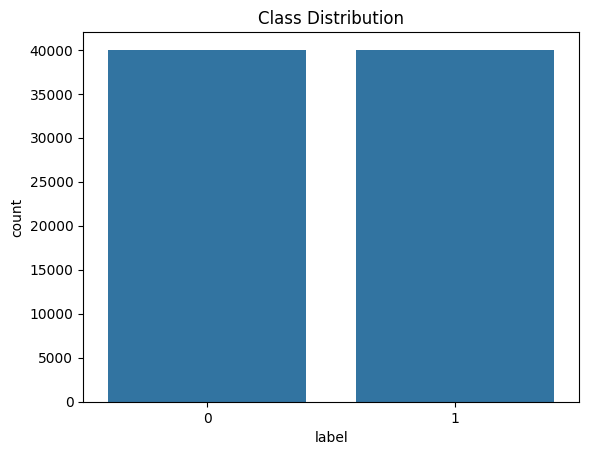

In [4]:
sns.countplot(x="label", data=train_df)
plt.title("Class Distribution")
plt.show()

In [5]:
eda_helper_functions.cat_summary(train_df, "label")

0        0
1        0
2        0
3        1
4        1
        ..
79989    0
79990    1
79991    0
79992    0
79993    0
Name: label, Length: 79994, dtype: int64

Data Type      : int64
Cardinality    : 2 categories
Missing Data   : 0 rows (0.00 %)
Available Data : 79,994 / 79,994 rows


,
count,79994.000000
mean,0.499850
std,0.500003
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


,count,percentage
category,,
0,40009,0.50015
1,39985,0.49985


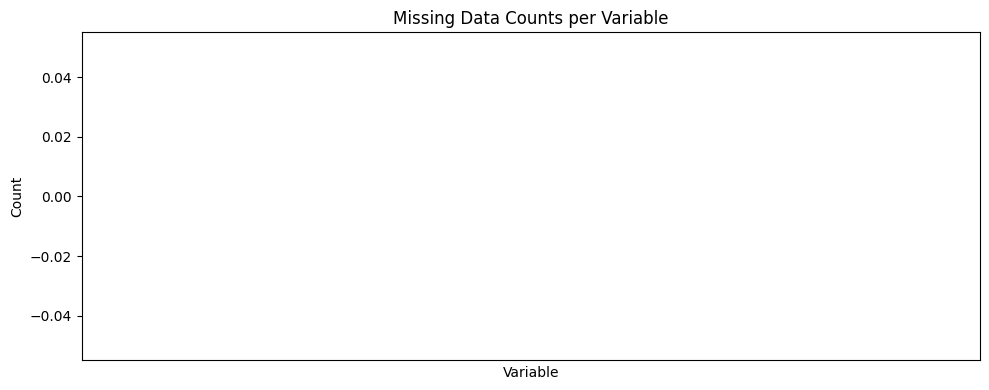

In [6]:
# Missing Values Check
eda_helper_functions.missing_info(train_df)
eda_helper_functions.plot_missing_info(train_df)

In [7]:
# Text Length Analysis 
train_df["text_length"] = train_df["text"].apply(len)

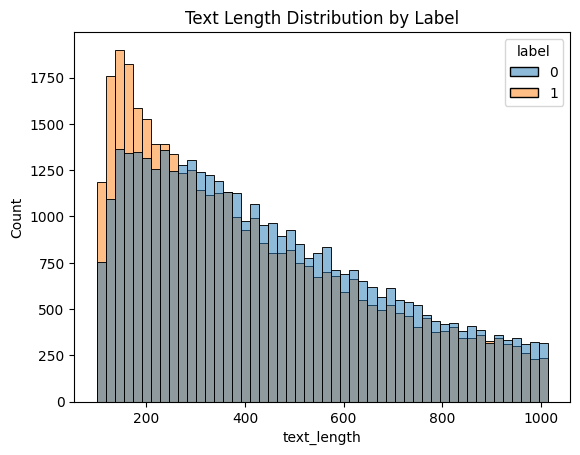

In [8]:
sns.histplot(data=train_df, x="text_length", hue="label", bins=50)
plt.title("Text Length Distribution by Label")
plt.show()

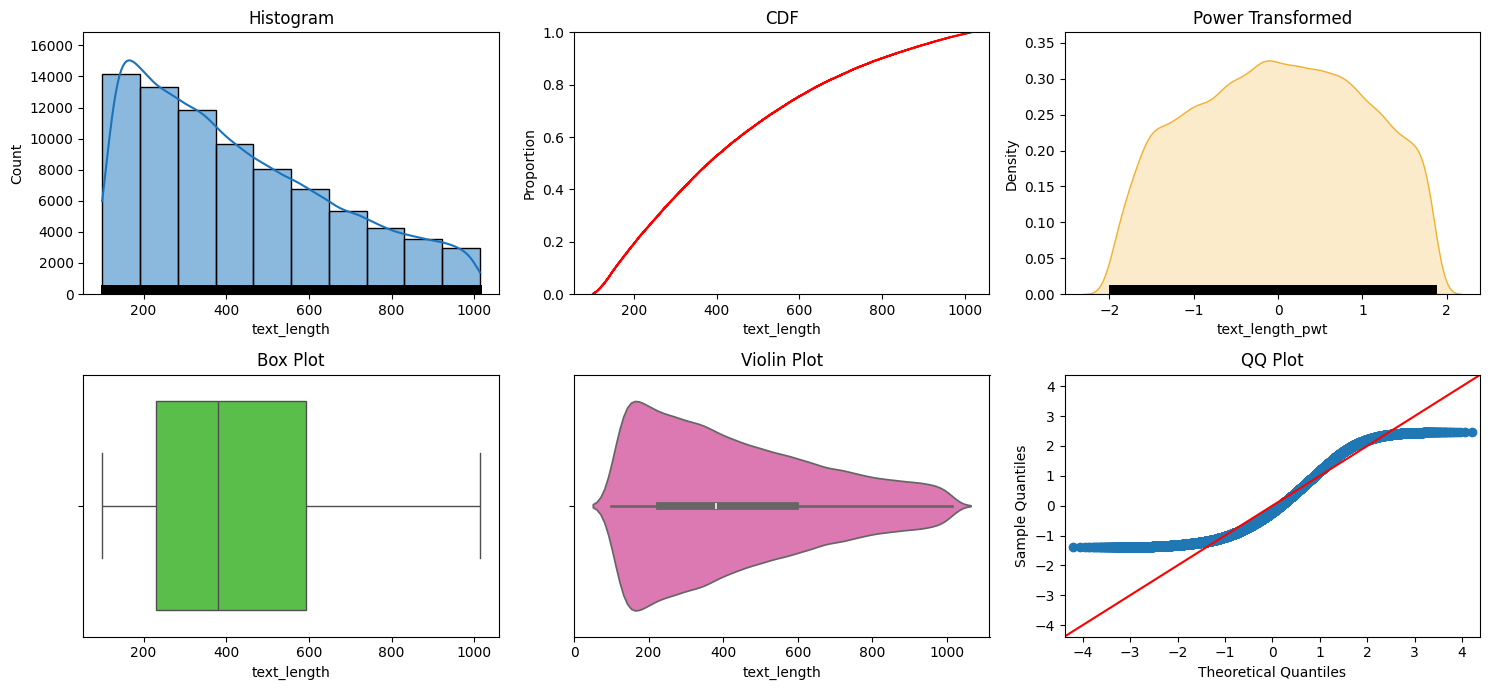

In [9]:
eda_helper_functions.num_univar_plots(train_df, "text_length")

In [10]:
# Word Count Analysis
train_df["word_count"] = train_df["clean_text"].apply(lambda x: len(x.split()))

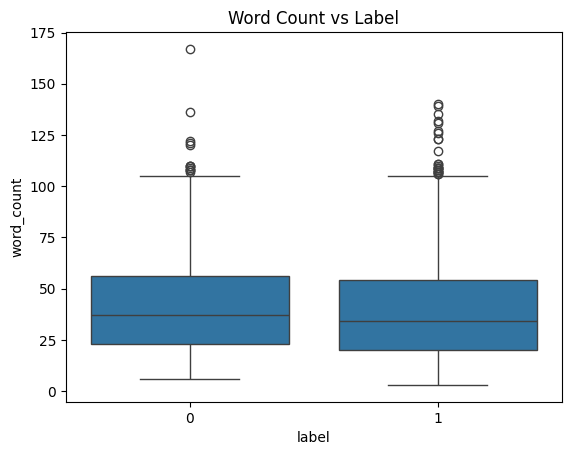

In [11]:
sns.boxplot(x="label", y="word_count", data=train_df)
plt.title("Word Count vs Label")
plt.show()

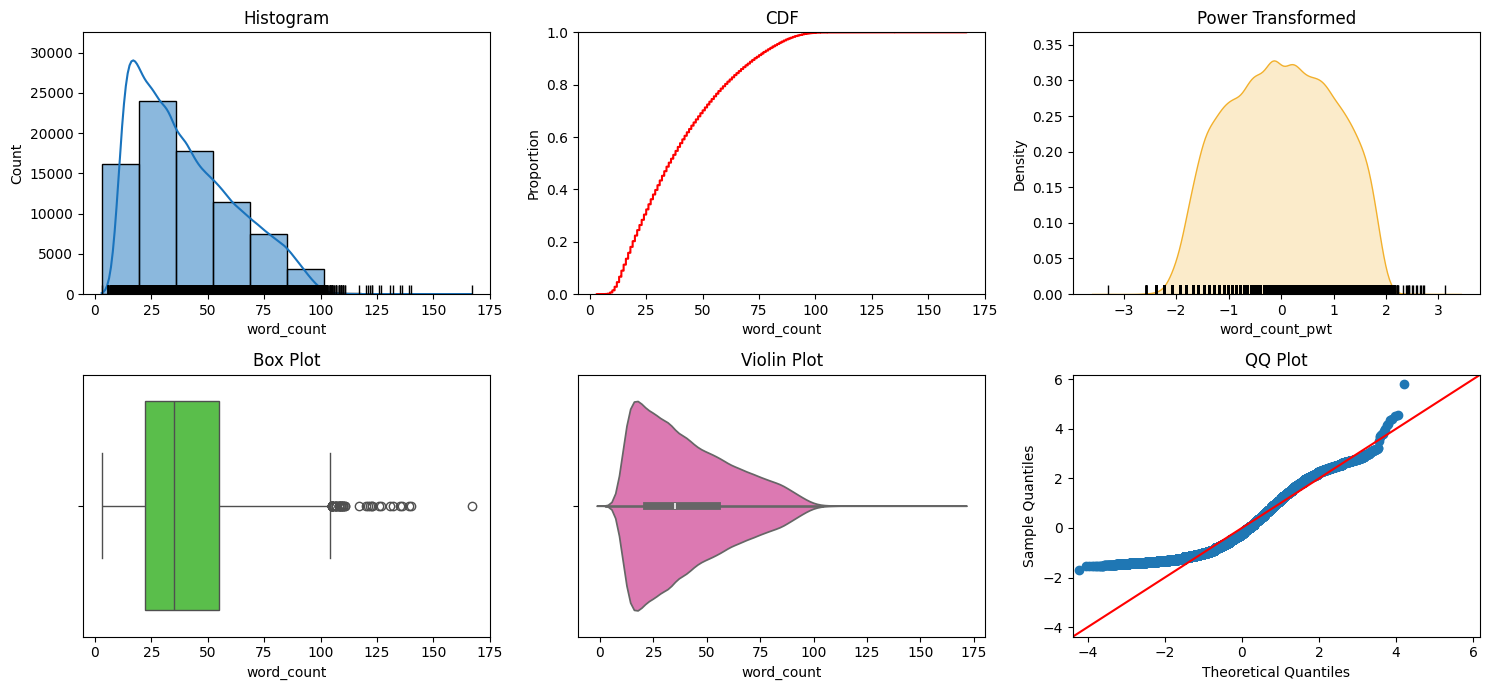

In [13]:
eda_helper_functions.num_univar_plots(train_df, "word_count")

In [15]:
# Common Words Analysis
from collections import Counter

# Fake Reviews (label = 0)
fake_words = " ".join(train_df[train_df["label"]==0]["clean_text"]).split()
Counter(fake_words).most_common(20)

# Real Reviews (label = 1)
real_words = " ".join(train_df[train_df["label"]==1]["clean_text"]).split()
Counter(real_words).most_common(20)

[('book', 25216),
 ('great', 18403),
 ('one', 15016),
 ('good', 13336),
 ('like', 11080),
 ('love', 9130),
 ('read', 8921),
 ('time', 8403),
 ('get', 7528),
 ('movie', 7143),
 ('well', 7086),
 ('would', 6872),
 ('best', 6855),
 ('really', 6519),
 ('work', 6161),
 ('cd', 5881),
 ('album', 5845),
 ('year', 5385),
 ('make', 5322),
 ('story', 5280)]

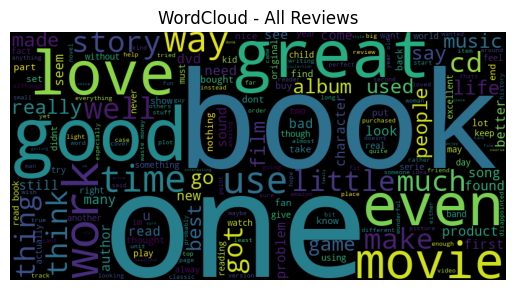

In [16]:
# WordCloud (All Data)
text = " ".join(train_df["clean_text"])

wc = WordCloud(width=800, height=400).generate(text)

plt.imshow(wc)
plt.axis("off")
plt.title("WordCloud - All Reviews")
plt.show()

In [17]:
# WordCloud (Fake vs Real)
fake_text = " ".join(train_df[train_df["label"]==0]["clean_text"])
real_text = " ".join(train_df[train_df["label"]==1]["clean_text"])

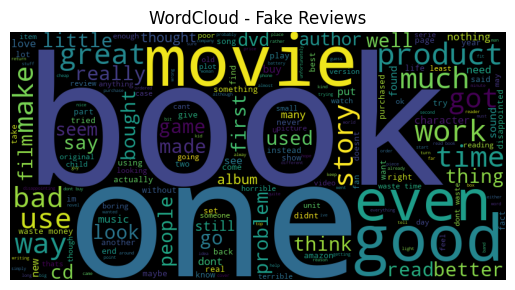

In [18]:
# Fake
wc_fake = WordCloud(width=800, height=400).generate(fake_text)

plt.imshow(wc_fake)
plt.axis("off")
plt.title("WordCloud - Fake Reviews")
plt.show()

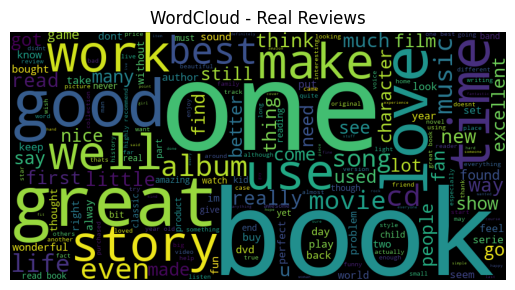

In [19]:
# Real
wc_real = WordCloud(width=800, height=400).generate(real_text)

plt.imshow(wc_real)
plt.axis("off")
plt.title("WordCloud - Real Reviews")
plt.show()

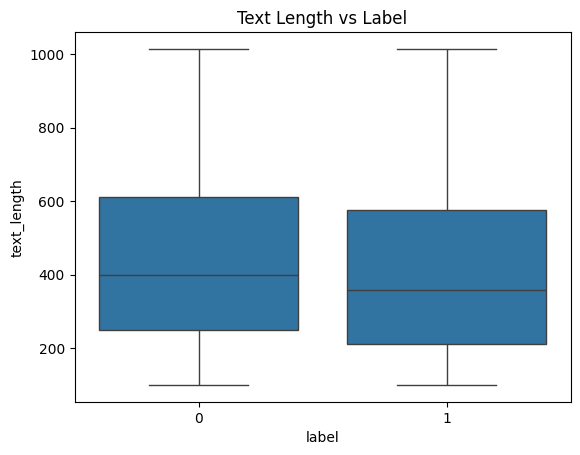

In [20]:
# Label vs Text Length (Bivariate)
sns.boxplot(x="label", y="text_length", data=train_df)
plt.title("Text Length vs Label")
plt.show()